In [1]:
import os 
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from PIL import Image
from PIL import ImageOps
from torchvision import transforms
from torch import nn
from torch.nn import functional as F

In [2]:
DATASET_PATH = r"D:\backend_plant_disease\Datasets\newdataset"
EPOCHS = 20
IMAGE_SIZE = 256
OUTPUT = r"D:\backend_plant_disease\Algorithm\runs\classify\pothos_resnet9new"
device = "cuda"
os.mkdir(OUTPUT) if not os.path.exists(OUTPUT) else None

In [3]:
# Extracting files and splitting them
sub_fold = os.listdir(DATASET_PATH)
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
train, val, test = [], [], []
for i, sub_fold in enumerate(os.listdir(DATASET_PATH)):
    sub_path = os.path.join(DATASET_PATH, sub_fold)
    files = [os.path.join(sub_path, f) for f in os.listdir(sub_path) if any(f.endswith(ext) for ext in extensions)]
    n = len(files)
    a,b = int(n*0.75), int(n*0.85)
    train += [(file, i) for file in files[:a]]
    val += [(file, i) for file in files[a:b]]
    test += [(file, i) for file in files[b:]]
    print(f"Class {sub_fold}: {len(files)} images, Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Class chlorosis: 263 images, Train: 197, Val: 26, Test: 40
Class healthy: 499 images, Train: 571, Val: 76, Test: 115
Class necrosis: 491 images, Train: 939, Val: 125, Test: 189


In [4]:
# Custom Class for Dataset
class LeafDataset(Dataset):
    def __init__(self, data, transform = None):
        self.data, self.transform = data, transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        image_path, label = self.data[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [5]:
# Preprocessiong and Data Transformations
def square(image):
    width, height = image.size
    size = max(width, height)
    top = (size - height) // 2
    left = (size - width) // 2
    right = size - width - left
    bottom = size - height - top
    return ImageOps.expand(image, (left, top, right, bottom), fill=(0, 0, 0))

train_transform = transforms.Compose([
    transforms.Lambda(square),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.05),
    transforms.ToTensor()])
eval_transform = transforms.Compose([
    transforms.Lambda(square),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()]) 

counts = [sum(i == label for _ , label in train) for i in range(3)]
weights = [1.0/counts[label] for _, label in train]
sampler = WeightedRandomSampler(torch.tensor(weights, dtype=torch.float64), len(train), replacement = True)

train_loader = DataLoader(LeafDataset(train, transform=train_transform), batch_size=32, sampler=sampler)
val_loader = DataLoader(LeafDataset(val, transform=eval_transform), batch_size=32, shuffle=False)
test_loader = DataLoader(LeafDataset(test, transform=eval_transform), batch_size=32, shuffle=False)


# Model Architecture: ResNet9
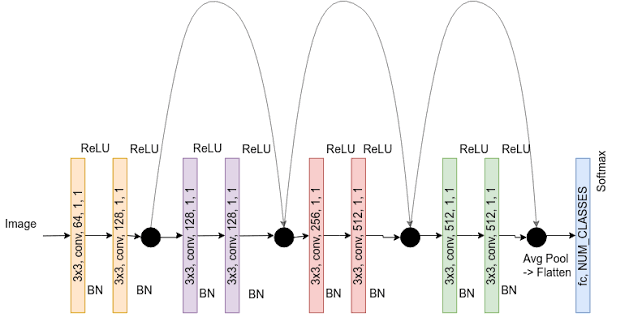

In [6]:
def block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, 3, padding=1),
              nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)]
    if pool:
        layers.append(nn.MaxPool2d(4))
    return nn.Sequential(*layers)


class ResNet9(nn.Module):
    # Same architecture as plant-disease-classification-resnet-99-2.ipynb
    def __init__(self, number_of_classes):
        super().__init__()
        self.conv1 = block(3, 64)
        self.conv2 = block(64, 128, pool=True)
        self.res1 = nn.Sequential(block(128, 128), block(128, 128))
        self.conv3 = block(128, 256, pool=True)
        self.conv4 = block(256, 512, pool=True)
        self.res2 = nn.Sequential(block(512, 512), block(512, 512))
        self.classifier = nn.Sequential(nn.MaxPool2d(4), nn.Flatten(),
                                        nn.Linear(512, number_of_classes))

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.res1(x) + x
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.res2(x) + x
        return self.classifier(x)

In [7]:
model = ResNet9(number_of_classes=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def accuracy(model, data_loader, device="cuda"):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images.to(device))
            correct += (outputs.argmax(1).cpu() == labels).sum().item()
            total += len(labels)
    return correct / total if total else 0.0

In [10]:
best_accuracy = 0.0
for epoch in range(EPOCHS):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        loss = F.cross_entropy(model(images), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_accuracy = accuracy(model, train_loader, device)
    val_accuracy = accuracy(model, val_loader, device)
    print(f"Epoch {epoch + 1:02d}/{EPOCHS} - training accuracy: {train_accuracy:.3f} - validation accuracy: {val_accuracy:.3f}")
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        torch.save(model.state_dict(), os.path.join(OUTPUT, "best.pt"))

Epoch 01/20 - training accuracy: 0.827 - validation accuracy: 0.920
Epoch 02/20 - training accuracy: 0.906 - validation accuracy: 0.872
Epoch 03/20 - training accuracy: 0.918 - validation accuracy: 0.816
Epoch 04/20 - training accuracy: 0.878 - validation accuracy: 0.616
Epoch 05/20 - training accuracy: 0.921 - validation accuracy: 0.816
Epoch 06/20 - training accuracy: 0.932 - validation accuracy: 0.816
Epoch 07/20 - training accuracy: 0.949 - validation accuracy: 0.736
Epoch 08/20 - training accuracy: 0.913 - validation accuracy: 0.920
Epoch 09/20 - training accuracy: 0.927 - validation accuracy: 0.776
Epoch 10/20 - training accuracy: 0.945 - validation accuracy: 0.760
Epoch 11/20 - training accuracy: 0.911 - validation accuracy: 0.752
Epoch 12/20 - training accuracy: 0.939 - validation accuracy: 0.816
Epoch 13/20 - training accuracy: 0.957 - validation accuracy: 0.816
Epoch 14/20 - training accuracy: 0.942 - validation accuracy: 0.832
Epoch 15/20 - training accuracy: 0.941 - validat

In [16]:
model_path = r"D:\backend_plant_disease\Algorithm\runs\classify\pothos_resnet9new\best.pt"

model = ResNet9(number_of_classes=3).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
correct, total = 0, 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        prediction = (outputs.argmax(1).cpu() == labels).sum().item()
        correct += prediction
        total += len(labels)
    accuracy = correct / total if total else 0.0
    print(f"Test accuracy: {accuracy:.3f}")
        

Test accuracy: 0.942


Predicted class: healthy


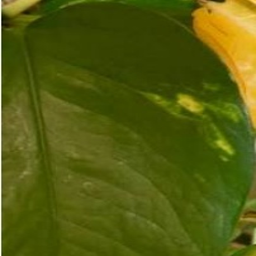

In [48]:
# Testing The model with a single image
CLASS_NAMES = ["chlorosis", "healthy", "necrosis"]
image_path = r"D:\backend_plant_disease\Datasets\custom_classification_dataset\ScreenShot_2026-09-03_162321_207_leaf_001.jpg"
image = Image.open(image_path).resize((IMAGE_SIZE, IMAGE_SIZE)).convert("RGB")


test_transform = transforms.Compose([
    transforms.Lambda(square),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()]) 

image_tensor = test_transform(image).unsqueeze(0)
with torch.no_grad():
    output = model(image_tensor.to(device))
t_pred = output.argmax(1).item()
print(f"Predicted class: {CLASS_NAMES[t_pred]}")
image
